In [11]:
# imports
import pyomo.environ as pe
import pyomo.opt as po
import math
import time as tm

# Optimize the Model

In [12]:
def optimize_model(tc):
    # -------------------------------------------------------------------------
    # SETS
    # -------------------------------------------------------------------------
    factories = ['IJmuiden', 'Segal', 'South Wales']
    customer_areas = ['Bochum', 'Boenen', 'Dortmund', 'Gelsenkirchen', 'Hagen', 'Iserlohn', 'Neuss', 'Schwerte']
    long_bar_types = ['1', '2']
    rebar_types = ['A', 'B', 'C']
    numOfPeriods = 4

    # Parameters needed for steel capacity/fleet capacity calculations
    length_lb = {'1': 9, '2': 12}
    length_rb = {'A': 2.4, 'B': 3.6, 'C': 4.2}
    diameter = {'1': 0.057, '2': 0.057, 'A': 0.057, 'B': 0.057, 'C': 0.057}
    density = 7.85  # t/m3

    # -------------------------------------------------------------------------
    # Steel and Vehicle capacity
    # -------------------------------------------------------------------------
    steel_capacity = {'IJmuiden': 12, 'Segal': 10, 'South Wales': 28}
    vehicle_capacity = 10  # tons

    # -------------------------------------------------------------------------
    # Transportation costs
    # -------------------------------------------------------------------------
    f_fleet = {'IJmuiden': 130, 'Segal': 150, 'South Wales': 100}
    c_fleet = {'IJmuiden': tc, 'Segal': tc, 'South Wales': tc}

    # -------------------------------------------------------------------------
    # Demand
    # -------------------------------------------------------------------------
    demand = {
        # Rebar A
        ('A', 1, 'Bochum'): 2,  ('A', 1, 'Boenen'): 4,  ('A', 1, 'Dortmund'): 2,  ('A', 1, 'Gelsenkirchen'): 5,
        ('A', 1, 'Hagen'): 19,  ('A', 1, 'Iserlohn'): 13, ('A', 1, 'Neuss'): 20, ('A', 1, 'Schwerte'): 4,

        ('A', 2, 'Bochum'): 6,  ('A', 2, 'Boenen'): 8,  ('A', 2, 'Dortmund'): 7,  ('A', 2, 'Gelsenkirchen'): 5,
        ('A', 2, 'Hagen'): 23,  ('A', 2, 'Iserlohn'): 19, ('A', 2, 'Neuss'): 16, ('A', 2, 'Schwerte'): 5,

        ('A', 3, 'Bochum'): 5,  ('A', 3, 'Boenen'): 5,  ('A', 3, 'Dortmund'): 6,  ('A', 3, 'Gelsenkirchen'): 5,
        ('A', 3, 'Hagen'): 25,  ('A', 3, 'Iserlohn'): 17, ('A', 3, 'Neuss'): 14, ('A', 3, 'Schwerte'): 3,

        ('A', 4, 'Bochum'): 3,  ('A', 4, 'Boenen'): 10, ('A', 4, 'Dortmund'): 5,  ('A', 4, 'Gelsenkirchen'): 5,
        ('A', 4, 'Hagen'): 16,  ('A', 4, 'Iserlohn'): 14, ('A', 4, 'Neuss'): 26, ('A', 4, 'Schwerte'): 4,

        # Rebar B
        ('B', 1, 'Bochum'): 4,  ('B', 1, 'Boenen'): 5,  ('B', 1, 'Dortmund'): 4,  ('B', 1, 'Gelsenkirchen'): 9,
        ('B', 1, 'Hagen'): 15,  ('B', 1, 'Iserlohn'): 22, ('B', 1, 'Neuss'): 12, ('B', 1, 'Schwerte'): 2,

        ('B', 2, 'Bochum'): 5,  ('B', 2, 'Boenen'): 8,  ('B', 2, 'Dortmund'): 5,  ('B', 2, 'Gelsenkirchen'): 10,
        ('B', 2, 'Hagen'): 33,  ('B', 2, 'Iserlohn'): 26, ('B', 2, 'Neuss'): 23, ('B', 2, 'Schwerte'): 8,

        ('B', 3, 'Bochum'): 7,  ('B', 3, 'Boenen'): 12, ('B', 3, 'Dortmund'): 8,  ('B', 3, 'Gelsenkirchen'): 6,
        ('B', 3, 'Hagen'): 31,  ('B', 3, 'Iserlohn'): 20, ('B', 3, 'Neuss'): 30, ('B', 3, 'Schwerte'): 2,

        ('B', 4, 'Bochum'): 8,  ('B', 4, 'Boenen'): 13, ('B', 4, 'Dortmund'): 10, ('B', 4, 'Gelsenkirchen'): 6,
        ('B', 4, 'Hagen'): 33,  ('B', 4, 'Iserlohn'): 27, ('B', 4, 'Neuss'): 30, ('B', 4, 'Schwerte'): 6,

        # Rebar C
        ('C', 1, 'Bochum'): 6,  ('C', 1, 'Boenen'): 6,  ('C', 1, 'Dortmund'): 7,  ('C', 1, 'Gelsenkirchen'): 10,
        ('C', 1, 'Hagen'): 12,  ('C', 1, 'Iserlohn'): 14, ('C', 1, 'Neuss'): 22, ('C', 1, 'Schwerte'): 5,

        ('C', 2, 'Bochum'): 7,  ('C', 2, 'Boenen'): 10, ('C', 2, 'Dortmund'): 6,  ('C', 2, 'Gelsenkirchen'): 9,
        ('C', 2, 'Hagen'): 35,  ('C', 2, 'Iserlohn'): 25, ('C', 2, 'Neuss'): 32, ('C', 2, 'Schwerte'): 6,

        ('C', 3, 'Bochum'): 7,  ('C', 3, 'Boenen'): 15, ('C', 3, 'Dortmund'): 4,  ('C', 3, 'Gelsenkirchen'): 9,
        ('C', 3, 'Hagen'): 33,  ('C', 3, 'Iserlohn'): 23, ('C', 3, 'Neuss'): 31, ('C', 3, 'Schwerte'): 7,

        ('C', 4, 'Bochum'): 7,  ('C', 4, 'Boenen'): 12, ('C', 4, 'Dortmund'): 12, ('C', 4, 'Gelsenkirchen'): 10,
        ('C', 4, 'Hagen'): 38,  ('C', 4, 'Iserlohn'): 24, ('C', 4, 'Neuss'): 31, ('C', 4, 'Schwerte'): 2,
    }

    # -------------------------------------------------------------------------
    # Distance between factories and customer areas in km
    # -------------------------------------------------------------------------
    dist = {
        ('IJmuiden', 'IJmuiden'): 0, ('IJmuiden', 'Segal'): 284, ('IJmuiden', 'South Wales'): 826,
        ('IJmuiden', 'Bochum'): 250, ('IJmuiden', 'Boenen'): 282, ('IJmuiden', 'Dortmund'): 266,
        ('IJmuiden', 'Gelsenkirchen'): 234, ('IJmuiden', 'Hagen'): 289, ('IJmuiden', 'Iserlohn'): 299,
        ('IJmuiden', 'Neuss'): 259, ('IJmuiden', 'Schwerte'): 279,

        ('Segal', 'IJmuiden'): 284, ('Segal', 'Segal'): 0, ('Segal', 'South Wales'): 750,
        ('Segal', 'Bochum'): 203, ('Segal', 'Boenen'): 242, ('Segal', 'Dortmund'): 222,
        ('Segal', 'Gelsenkirchen'): 198, ('Segal', 'Hagen'): 206, ('Segal', 'Iserlohn'): 226,
        ('Segal', 'Neuss'): 140, ('Segal', 'Schwerte'): 216,

        ('South Wales', 'IJmuiden'): 826, ('South Wales', 'Segal'): 750, ('South Wales', 'South Wales'): 0,
        ('South Wales', 'Bochum'): 866, ('South Wales', 'Boenen'): 914, ('South Wales', 'Dortmund'): 885,
        ('South Wales', 'Gelsenkirchen'): 859, ('South Wales', 'Hagen'): 903, ('South Wales', 'Iserlohn'): 913,
        ('South Wales', 'Neuss'): 843, ('South Wales', 'Schwerte'): 901,

        ('Bochum', 'IJmuiden'): 250, ('Bochum', 'Segal'): 203, ('Bochum', 'South Wales'): 866,
        ('Bochum', 'Bochum'): 0, ('Bochum', 'Boenen'): 55, ('Bochum', 'Dortmund'): 21,
        ('Bochum', 'Gelsenkirchen'): 19, ('Bochum', 'Hagen'): 41, ('Bochum', 'Iserlohn'): 51,
        ('Bochum', 'Neuss'): 56, ('Bochum', 'Schwerte'): 39,

        ('Boenen', 'IJmuiden'): 282, ('Boenen', 'Segal'): 242, ('Boenen', 'South Wales'): 914,
        ('Boenen', 'Bochum'): 55, ('Boenen', 'Boenen'): 0, ('Boenen', 'Dortmund'): 34,
        ('Boenen', 'Gelsenkirchen'): 56, ('Boenen', 'Hagen'): 44, ('Boenen', 'Iserlohn'): 54,
        ('Boenen', 'Neuss'): 102, ('Boenen', 'Schwerte'): 32,

        ('Dortmund', 'IJmuiden'): 266, ('Dortmund', 'Segal'): 222, ('Dortmund', 'South Wales'): 885,
        ('Dortmund', 'Bochum'): 21, ('Dortmund', 'Boenen'): 34, ('Dortmund', 'Dortmund'): 0,
        ('Dortmund', 'Gelsenkirchen'): 34, ('Dortmund', 'Hagen'): 21, ('Dortmund', 'Iserlohn'): 36,
        ('Dortmund', 'Neuss'): 75, ('Dortmund', 'Schwerte'): 15,

        ('Gelsenkirchen', 'IJmuiden'): 234, ('Gelsenkirchen', 'Segal'): 198, ('Gelsenkirchen', 'South Wales'): 859,
        ('Gelsenkirchen', 'Bochum'): 19, ('Gelsenkirchen', 'Boenen'): 56, ('Gelsenkirchen', 'Dortmund'): 34,
        ('Gelsenkirchen', 'Gelsenkirchen'): 0, ('Gelsenkirchen', 'Hagen'): 56, ('Gelsenkirchen', 'Iserlohn'): 66,
        ('Gelsenkirchen', 'Neuss'): 62, ('Gelsenkirchen', 'Schwerte'): 54,

        ('Hagen', 'IJmuiden'): 289, ('Hagen', 'Segal'): 206, ('Hagen', 'South Wales'): 903,
        ('Hagen', 'Bochum'): 41, ('Hagen', 'Boenen'): 44, ('Hagen', 'Dortmund'): 21,
        ('Hagen', 'Gelsenkirchen'): 56, ('Hagen', 'Hagen'): 0, ('Hagen', 'Iserlohn'): 20,
        ('Hagen', 'Neuss'): 66, ('Hagen', 'Schwerte'): 14,

        ('Iserlohn', 'IJmuiden'): 299, ('Iserlohn', 'Segal'): 226, ('Iserlohn', 'South Wales'): 913,
        ('Iserlohn', 'Bochum'): 51, ('Iserlohn', 'Boenen'): 54, ('Iserlohn', 'Dortmund'): 36,
        ('Iserlohn', 'Gelsenkirchen'): 66, ('Iserlohn', 'Hagen'): 20, ('Iserlohn', 'Iserlohn'): 0,
        ('Iserlohn', 'Neuss'): 85, ('Iserlohn', 'Schwerte'): 15,

        ('Neuss', 'IJmuiden'): 259, ('Neuss', 'Segal'): 140, ('Neuss', 'South Wales'): 843,
        ('Neuss', 'Bochum'): 56, ('Neuss', 'Boenen'): 102, ('Neuss', 'Dortmund'): 75,
        ('Neuss', 'Gelsenkirchen'): 62, ('Neuss', 'Hagen'): 66, ('Neuss', 'Iserlohn'): 85,
        ('Neuss', 'Neuss'): 0, ('Neuss', 'Schwerte'): 75,

        ('Schwerte', 'IJmuiden'): 279, ('Schwerte', 'Segal'): 216, ('Schwerte', 'South Wales'): 901,
        ('Schwerte', 'Bochum'): 39, ('Schwerte', 'Boenen'): 32, ('Schwerte', 'Dortmund'): 15,
        ('Schwerte', 'Gelsenkirchen'): 54, ('Schwerte', 'Hagen'): 14, ('Schwerte', 'Iserlohn'): 15,
        ('Schwerte', 'Neuss'): 75, ('Schwerte', 'Schwerte'): 0,
    }

    inv_capacity = {
        'Bochum': 10,
        'Boenen': 7,
        'Dortmund': 12,
        'Gelsenkirchen': 10,
        'Hagen': 12,
        'Iserlohn': 9,
        'Neuss': 8,
        'Schwerte': 5,
    }


    # -------------------------------------------------------------------------
    # Preprocessing: weights, patterns, tightening parameters
    # -------------------------------------------------------------------------
    radius = diameter['A'] / 2
    weights_lb = {l: math.pi * (radius ** 2) * length_lb[l] * density for l in long_bar_types}
    weights_rb = {r: math.pi * (radius ** 2) * length_rb[r] * density for r in rebar_types}

    customer_weight = {}
    for c in customer_areas:
        for t in range(1, numOfPeriods + 1):
            customer_weight[c, t] = sum(demand[r, t, c] * weights_rb[r] for r in rebar_types)

    def generate_patterns(long_length, rebar_lengths):
        patterns = []
        max_A = int(long_length // rebar_lengths['A'])
        max_B = int(long_length // rebar_lengths['B'])
        max_C = int(long_length // rebar_lengths['C'])

        for a in range(max_A + 1):
            for b in range(max_B + 1):
                for c in range(max_C + 1):
                    total_len = a * rebar_lengths['A'] + b * rebar_lengths['B'] + c * rebar_lengths['C']
                    if 0 < total_len <= long_length:
                        patterns.append({
                            'A': a,
                            'B': b,
                            'C': c,
                            'used_len': total_len
                        })
        return patterns

    def filter_nondominated_patterns(patterns):
        nondom = []
        for p in patterns:
            dominated = False
            for q in patterns:
                if p is q:
                    continue

                produces_more_or_equal = (
                    q['A'] >= p['A'] and
                    q['B'] >= p['B'] and
                    q['C'] >= p['C']
                )
                uses_less_or_equal_length = q['used_len'] <= p['used_len']
                strictly_better_somewhere = (
                    q['A'] > p['A'] or
                    q['B'] > p['B'] or
                    q['C'] > p['C'] or
                    q['used_len'] < p['used_len']
                )

                if produces_more_or_equal and uses_less_or_equal_length and strictly_better_somewhere:
                    dominated = True
                    break

            if not dominated:
                nondom.append({'A': p['A'], 'B': p['B'], 'C': p['C']})
        return nondom

    patterns_1 = filter_nondominated_patterns(generate_patterns(length_lb['1'], length_rb))
    patterns_2 = filter_nondominated_patterns(generate_patterns(length_lb['2'], length_rb))

    # Remaining demand from period t onward
    remaining_demand = {}
    future_demand = {}

    for r in rebar_types:
        for c in customer_areas:
            for t in range(1, numOfPeriods + 1):
                remaining_demand[r, c, t] = sum(demand[r, tau, c] for tau in range(t, numOfPeriods + 1))
                if t < numOfPeriods:
                    future_demand[r, c, t] = sum(demand[r, tau, c] for tau in range(t + 1, numOfPeriods + 1))
                else:
                    future_demand[r, c, t] = 0

    # Tight M values for production activation
    M1 = {f: math.floor(steel_capacity[f] / weights_lb['1']) for f in factories}
    M2 = {f: math.floor(steel_capacity[f] / weights_lb['2']) for f in factories}

    # -------------------------------------------------------------------------
    # Model
    # -------------------------------------------------------------------------
    model = pe.ConcreteModel(name="Production_Delivery_Planning_With_Inventory")

    # Sets
    model.F = pe.Set(initialize=factories)
    model.C = pe.Set(initialize=customer_areas)
    model.N = pe.Set(initialize=factories + customer_areas)
    model.T = pe.Set(initialize=range(1, numOfPeriods + 1))
    model.L = pe.Set(initialize=long_bar_types)
    model.R = pe.Set(initialize=rebar_types)
    model.P1 = pe.Set(initialize=range(len(patterns_1)))
    model.P2 = pe.Set(initialize=range(len(patterns_2)))

    # Allowed routing arcs:
    # for each factory f, only on local nodes {f} U C, without self-loops
    def allowed_arcs_init(model):
        arcs = []
        for f in factories:
            local_nodes = [f] + customer_areas
            for i in local_nodes:
                for j in local_nodes:
                    if i != j:
                        arcs.append((f, i, j))
        return arcs

    model.A = pe.Set(dimen=3, initialize=allowed_arcs_init)

    # Parameters
    model.dist = pe.Param(model.N, model.N, initialize=dist)
    model.demand = pe.Param(model.R, model.T, model.C, initialize=lambda m, r, t, c: demand.get((r, t, c), 0))
    model.steel_capacity = pe.Param(model.F, initialize=steel_capacity)
    model.vehicle_capacity = pe.Param(initialize=vehicle_capacity)
    model.f_fleet = pe.Param(model.F, initialize=f_fleet, within=pe.NonNegativeReals)
    model.c_fleet = pe.Param(model.F, initialize=c_fleet, within=pe.NonNegativeReals)
    model.weights_lb = pe.Param(model.L, initialize=weights_lb)
    model.weights_rb = pe.Param(model.R, initialize=weights_rb)
    model.customer_weight = pe.Param(model.C, model.T, initialize=customer_weight)
    model.inv_capacity = pe.Param(model.C, initialize=inv_capacity)
    model.remaining_demand = pe.Param(model.R, model.C, model.T, initialize=remaining_demand)
    model.future_demand = pe.Param(model.R, model.C, model.T, initialize=future_demand)

    # -------------------------------------------------------------------------
    # Decision Variables
    # -------------------------------------------------------------------------
    model.x1 = pe.Var(model.F, model.P1, model.T, domain=pe.NonNegativeIntegers)
    model.x2 = pe.Var(model.F, model.P2, model.T, domain=pe.NonNegativeIntegers)

    model.y = pe.Var(model.F, model.C, model.T, domain=pe.Binary)
    model.z = pe.Var(model.A, model.T, domain=pe.Binary)
    model.w = pe.Var(model.F, model.T, domain=pe.Binary)

    model.u = pe.Var(model.F, model.C, model.T, domain=pe.NonNegativeReals, bounds=(0, len(customer_areas)))

    model.I = pe.Var(model.R, model.C, model.T, domain=pe.NonNegativeIntegers)
    model.q = pe.Var(model.F, model.R, model.C, model.T, domain=pe.NonNegativeIntegers)

    # -------------------------------------------------------------------------
    # Objective Function
    # -------------------------------------------------------------------------
    def obj_rule(model):
        routing_cost = sum(
            model.z[f, i, j, t] * model.dist[i, j] * model.c_fleet[f]
            for (f, i, j) in model.A for t in model.T
        )
        fixed_cost = sum(model.w[f, t] * model.f_fleet[f] for f in model.F for t in model.T)
        return routing_cost + fixed_cost

    model.Obj = pe.Objective(rule=obj_rule, sense=pe.minimize)


    # -------------------------------------------------------------------------
    # Constraints
    # -------------------------------------------------------------------------

    # A customer is served by at most one factory in a period
    def assign_rule(model, c, t):
        return sum(model.y[f, c, t] for f in model.F) <= 1
    model.AssignConstraint = pe.Constraint(model.C, model.T, rule=assign_rule)

    # Production must cover what is shipped
    def link_prod_rule(model, f, r, t):
        prod1 = sum(patterns_1[p][r] * model.x1[f, p, t] for p in model.P1)
        prod2 = sum(patterns_2[p][r] * model.x2[f, p, t] for p in model.P2)
        shipped = sum(model.q[f, r, c, t] for c in model.C)
        return prod1 + prod2 >= shipped
    model.LinkProdConstraint = pe.Constraint(model.F, model.R, model.T, rule=link_prod_rule)

    # Inventory balance
    def inv_balance_rule(model, r, c, t):
        inbound = sum(model.q[f, r, c, t] for f in model.F)
        if t == 1:
            return model.I[r, c, t] == inbound - model.demand[r, t, c]
        return model.I[r, c, t] == model.I[r, c, t - 1] + inbound - model.demand[r, t, c]
    model.InvBalance = pe.Constraint(model.R, model.C, model.T, rule=inv_balance_rule)

    # Shipment only if assigned, using a tighter M = remaining demand
    def ship_if_assigned_rule(model, f, r, c, t):
        return model.q[f, r, c, t] <= model.remaining_demand[r, c, t] * model.y[f, c, t]
    model.ShipIfAssigned = pe.Constraint(model.F, model.R, model.C, model.T, rule=ship_if_assigned_rule)

    # If customer is visited, at least one rebar must be delivered
    def deliver_if_visit_rule(model, f, c, t):
        return sum(model.q[f, r, c, t] for r in model.R) >= model.y[f, c, t]
    model.DeliverIfVisit = pe.Constraint(model.F, model.C, model.T, rule=deliver_if_visit_rule)

    # Vehicle capacity
    def vehicle_cap_rule(model, f, t):
        shipped_weight = sum(model.q[f, r, c, t] * model.weights_rb[r] for r in model.R for c in model.C)
        return shipped_weight <= model.vehicle_capacity * model.w[f, t]
    model.VehicleCapConstraint = pe.Constraint(model.F, model.T, rule=vehicle_cap_rule)

    # Inventory capacity
    def inv_cap_rule(model, c, t):
        return sum(model.I[r, c, t] * model.weights_rb[r] for r in model.R) <= model.inv_capacity[c]
    model.InvCap = pe.Constraint(model.C, model.T, rule=inv_cap_rule)

    # Inventory at end of horizon should be zero
    def final_inventory_rule(model, r, c):
        return model.I[r, c, numOfPeriods] == 0
    model.FinalInventory = pe.Constraint(model.R, model.C, rule=final_inventory_rule)

    # Inventory should never exceed future demand
    def inv_future_demand_rule(model, r, c, t):
        return model.I[r, c, t] <= model.future_demand[r, c, t]
    model.InvFutureDemand = pe.Constraint(model.R, model.C, model.T, rule=inv_future_demand_rule)

    # Routing: leave factory if active
    def leave_factory_rule(model, f, t):
        return sum(model.z[f, f, j, t] for j in model.C) == model.w[f, t]
    model.LeaveFactoryConstraint = pe.Constraint(model.F, model.T, rule=leave_factory_rule)

    # Routing: return to factory if active
    def return_factory_rule(model, f, t):
        return sum(model.z[f, i, f, t] for i in model.C) == model.w[f, t]
    model.ReturnFactoryConstraint = pe.Constraint(model.F, model.T, rule=return_factory_rule)

    # Routing: flow into visited customer
    def flow_in_rule(model, f, c, t):
        return sum(
            model.z[f, i, c, t]
            for i in [f] + customer_areas
            if i != c and (f, i, c) in model.A
        ) == model.y[f, c, t]
    model.FlowInConstraint = pe.Constraint(model.F, model.C, model.T, rule=flow_in_rule)

    # Routing: flow out of visited customer
    def flow_out_rule(model, f, c, t):
        return sum(
            model.z[f, c, j, t]
            for j in [f] + customer_areas
            if j != c and (f, c, j) in model.A
        ) == model.y[f, c, t]
    model.FlowOutConstraint = pe.Constraint(model.F, model.C, model.T, rule=flow_out_rule)

    # MTZ subtour elimination
    def mtz_rule(model, f, i, j, t):
        if i != j:
            return model.u[f, i, t] - model.u[f, j, t] + len(customer_areas) * model.z[f, i, j, t] <= len(customer_areas) - 1
        return pe.Constraint.Skip
    model.MTZConstraint = pe.Constraint(model.F, model.C, model.C, model.T, rule=mtz_rule)

    # Strengthen MTZ: u only positive if customer is assigned
    def u_upper_rule(model, f, c, t):
        return model.u[f, c, t] <= len(customer_areas) * model.y[f, c, t]
    model.UUpperConstraint = pe.Constraint(model.F, model.C, model.T, rule=u_upper_rule)

    def u_lower_rule(model, f, c, t):
        return model.u[f, c, t] >= model.y[f, c, t]
    model.ULowerConstraint = pe.Constraint(model.F, model.C, model.T, rule=u_lower_rule)

    # Factory capacity only if active
    def factory_cap_if_active_rule(model, f, t):
        weight_1 = sum(model.x1[f, p, t] * model.weights_lb['1'] for p in model.P1)
        weight_2 = sum(model.x2[f, p, t] * model.weights_lb['2'] for p in model.P2)
        return weight_1 + weight_2 <= model.steel_capacity[f] * model.w[f, t]
    model.FactoryCapIfActive = pe.Constraint(model.F, model.T, rule=factory_cap_if_active_rule)

    # Tight production activation constraints
    def prod_only_if_active_1_rule(model, f, t):
        return sum(model.x1[f, p, t] for p in model.P1) <= M1[f] * model.w[f, t]
    model.ProdOnlyIfActive1 = pe.Constraint(model.F, model.T, rule=prod_only_if_active_1_rule)

    def prod_only_if_active_2_rule(model, f, t):
        return sum(model.x2[f, p, t] for p in model.P2) <= M2[f] * model.w[f, t]
    model.ProdOnlyIfActive2 = pe.Constraint(model.F, model.T, rule=prod_only_if_active_2_rule)

    # If customer assigned to factory, factory must be active
    def y_implies_w_rule(model, f, c, t):
        return model.y[f, c, t] <= model.w[f, t]
    model.YImpliesW = pe.Constraint(model.F, model.C, model.T, rule=y_implies_w_rule)

    # -------------------------------------------------------------------------
    # Solve
    # -------------------------------------------------------------------------
    solver = po.SolverFactory('gurobi')
    result = solver.solve(
        model,
        tee=True,
        options={
            'TimeLimit': 3600
        }
    )

    print(f"\nOptimization Status: {result.solver.status}")
    print(f"Termination Condition: {result.solver.termination_condition}")
    if result.solver.status == po.SolverStatus.ok:
        print(f"Total Objective Cost: €{pe.value(model.Obj):.2f}")

    # -------------------------------------------------------------------------
    # Print results
    # -------------------------------------------------------------------------
    print(f"\n============================= TC = €{tc} =======================================")
    print("\nOptimal production, delivery and inventory plan")

    for t in model.T:
        print(f"\n================ PERIOD {t} ================")

        for f in model.F:
            if pe.value(model.w[f, t]) > 0.5:
                print(f"\nFactory: {f}")
                total_steel_used = 0

                # Production
                print("\n Production:")
                for p in model.P1:
                    val = pe.value(model.x1[f, p, t])
                    if val is not None and val > 1e-6:
                        bars = int(round(val))
                        total_steel_used += bars * weights_lb['1']
                        print(f"  • {bars}x 9m bars with pattern {patterns_1[p]}")

                for p in model.P2:
                    val = pe.value(model.x2[f, p, t])
                    if val is not None and val > 1e-6:
                        bars = int(round(val))
                        total_steel_used += bars * weights_lb['2']
                        print(f"  • {bars}x 12m bars with pattern {patterns_2[p]}")

                print(f"  Steel used: {total_steel_used:.2f} / {steel_capacity[f]} tonnes")

                # Route
                print("\n Delivery Route:")
                curr_node = f
                route = [curr_node]
                visited_guard = set()

                while True:
                    next_node = None
                    for j in [f] + customer_areas:
                        if curr_node != j and (f, curr_node, j) in model.A:
                            val = pe.value(model.z[f, curr_node, j, t])
                            if val is not None and val > 0.5:
                                next_node = j
                                break

                    if next_node is None:
                        break

                    if next_node == f:
                        route.append(f)
                        break
def optimize_model(tc):
    # -------------------------------------------------------------------------
    # SETS
    # -------------------------------------------------------------------------
    factories = ['IJmuiden', 'Segal', 'South Wales']
    customer_areas = ['Bochum', 'Boenen', 'Dortmund', 'Gelsenkirchen', 'Hagen', 'Iserlohn', 'Neuss', 'Schwerte']
    long_bar_types = ['1', '2']
    rebar_types = ['A', 'B', 'C']
    numOfPeriods = 4

    # Parameters needed for steel capacity/fleet capacity calculations
    length_lb = {'1': 9, '2': 12}
    length_rb = {'A': 2.4, 'B': 3.6, 'C': 4.2}
    diameter = {'1': 0.057, '2': 0.057, 'A': 0.057, 'B': 0.057, 'C': 0.057}
    density = 7.85  # t/m3

    # -------------------------------------------------------------------------
    # Steel and Vehicle capacity
    # -------------------------------------------------------------------------
    steel_capacity = {'IJmuiden': 12, 'Segal': 10, 'South Wales': 28}
    vehicle_capacity = 10  # tons

    # -------------------------------------------------------------------------
    # Transportation costs
    # -------------------------------------------------------------------------
    f_fleet = {'IJmuiden': 130, 'Segal': 150, 'South Wales': 100}
    c_fleet = {'IJmuiden': tc, 'Segal': tc, 'South Wales': tc}

    # -------------------------------------------------------------------------
    # Demand
    # -------------------------------------------------------------------------
    demand = {
        # Rebar A
        ('A', 1, 'Bochum'): 2,  ('A', 1, 'Boenen'): 4,  ('A', 1, 'Dortmund'): 2,  ('A', 1, 'Gelsenkirchen'): 5,
        ('A', 1, 'Hagen'): 19,  ('A', 1, 'Iserlohn'): 13, ('A', 1, 'Neuss'): 20, ('A', 1, 'Schwerte'): 4,

        ('A', 2, 'Bochum'): 6,  ('A', 2, 'Boenen'): 8,  ('A', 2, 'Dortmund'): 7,  ('A', 2, 'Gelsenkirchen'): 5,
        ('A', 2, 'Hagen'): 23,  ('A', 2, 'Iserlohn'): 19, ('A', 2, 'Neuss'): 16, ('A', 2, 'Schwerte'): 5,

        ('A', 3, 'Bochum'): 5,  ('A', 3, 'Boenen'): 5,  ('A', 3, 'Dortmund'): 6,  ('A', 3, 'Gelsenkirchen'): 5,
        ('A', 3, 'Hagen'): 25,  ('A', 3, 'Iserlohn'): 17, ('A', 3, 'Neuss'): 14, ('A', 3, 'Schwerte'): 3,

        ('A', 4, 'Bochum'): 3,  ('A', 4, 'Boenen'): 10, ('A', 4, 'Dortmund'): 5,  ('A', 4, 'Gelsenkirchen'): 5,
        ('A', 4, 'Hagen'): 16,  ('A', 4, 'Iserlohn'): 14, ('A', 4, 'Neuss'): 26, ('A', 4, 'Schwerte'): 4,

        # Rebar B
        ('B', 1, 'Bochum'): 4,  ('B', 1, 'Boenen'): 5,  ('B', 1, 'Dortmund'): 4,  ('B', 1, 'Gelsenkirchen'): 9,
        ('B', 1, 'Hagen'): 15,  ('B', 1, 'Iserlohn'): 22, ('B', 1, 'Neuss'): 12, ('B', 1, 'Schwerte'): 2,

        ('B', 2, 'Bochum'): 5,  ('B', 2, 'Boenen'): 8,  ('B', 2, 'Dortmund'): 5,  ('B', 2, 'Gelsenkirchen'): 10,
        ('B', 2, 'Hagen'): 33,  ('B', 2, 'Iserlohn'): 26, ('B', 2, 'Neuss'): 23, ('B', 2, 'Schwerte'): 8,

        ('B', 3, 'Bochum'): 7,  ('B', 3, 'Boenen'): 12, ('B', 3, 'Dortmund'): 8,  ('B', 3, 'Gelsenkirchen'): 6,
        ('B', 3, 'Hagen'): 31,  ('B', 3, 'Iserlohn'): 20, ('B', 3, 'Neuss'): 30, ('B', 3, 'Schwerte'): 2,

        ('B', 4, 'Bochum'): 8,  ('B', 4, 'Boenen'): 13, ('B', 4, 'Dortmund'): 10, ('B', 4, 'Gelsenkirchen'): 6,
        ('B', 4, 'Hagen'): 33,  ('B', 4, 'Iserlohn'): 27, ('B', 4, 'Neuss'): 30, ('B', 4, 'Schwerte'): 6,

        # Rebar C
        ('C', 1, 'Bochum'): 6,  ('C', 1, 'Boenen'): 6,  ('C', 1, 'Dortmund'): 7,  ('C', 1, 'Gelsenkirchen'): 10,
        ('C', 1, 'Hagen'): 12,  ('C', 1, 'Iserlohn'): 14, ('C', 1, 'Neuss'): 22, ('C', 1, 'Schwerte'): 5,

        ('C', 2, 'Bochum'): 7,  ('C', 2, 'Boenen'): 10, ('C', 2, 'Dortmund'): 6,  ('C', 2, 'Gelsenkirchen'): 9,
        ('C', 2, 'Hagen'): 35,  ('C', 2, 'Iserlohn'): 25, ('C', 2, 'Neuss'): 32, ('C', 2, 'Schwerte'): 6,

        ('C', 3, 'Bochum'): 7,  ('C', 3, 'Boenen'): 15, ('C', 3, 'Dortmund'): 4,  ('C', 3, 'Gelsenkirchen'): 9,
        ('C', 3, 'Hagen'): 33,  ('C', 3, 'Iserlohn'): 23, ('C', 3, 'Neuss'): 31, ('C', 3, 'Schwerte'): 7,

        ('C', 4, 'Bochum'): 7,  ('C', 4, 'Boenen'): 12, ('C', 4, 'Dortmund'): 12, ('C', 4, 'Gelsenkirchen'): 10,
        ('C', 4, 'Hagen'): 38,  ('C', 4, 'Iserlohn'): 24, ('C', 4, 'Neuss'): 31, ('C', 4, 'Schwerte'): 2,
    }

    # -------------------------------------------------------------------------
    # Distance between factories and customer areas in km
    # -------------------------------------------------------------------------
    dist = {
        ('IJmuiden', 'IJmuiden'): 0, ('IJmuiden', 'Segal'): 284, ('IJmuiden', 'South Wales'): 826,
        ('IJmuiden', 'Bochum'): 250, ('IJmuiden', 'Boenen'): 282, ('IJmuiden', 'Dortmund'): 266,
        ('IJmuiden', 'Gelsenkirchen'): 234, ('IJmuiden', 'Hagen'): 289, ('IJmuiden', 'Iserlohn'): 299,
        ('IJmuiden', 'Neuss'): 259, ('IJmuiden', 'Schwerte'): 279,

        ('Segal', 'IJmuiden'): 284, ('Segal', 'Segal'): 0, ('Segal', 'South Wales'): 750,
        ('Segal', 'Bochum'): 203, ('Segal', 'Boenen'): 242, ('Segal', 'Dortmund'): 222,
        ('Segal', 'Gelsenkirchen'): 198, ('Segal', 'Hagen'): 206, ('Segal', 'Iserlohn'): 226,
        ('Segal', 'Neuss'): 140, ('Segal', 'Schwerte'): 216,

        ('South Wales', 'IJmuiden'): 826, ('South Wales', 'Segal'): 750, ('South Wales', 'South Wales'): 0,
        ('South Wales', 'Bochum'): 866, ('South Wales', 'Boenen'): 914, ('South Wales', 'Dortmund'): 885,
        ('South Wales', 'Gelsenkirchen'): 859, ('South Wales', 'Hagen'): 903, ('South Wales', 'Iserlohn'): 913,
        ('South Wales', 'Neuss'): 843, ('South Wales', 'Schwerte'): 901,

        ('Bochum', 'IJmuiden'): 250, ('Bochum', 'Segal'): 203, ('Bochum', 'South Wales'): 866,
        ('Bochum', 'Bochum'): 0, ('Bochum', 'Boenen'): 55, ('Bochum', 'Dortmund'): 21,
        ('Bochum', 'Gelsenkirchen'): 19, ('Bochum', 'Hagen'): 41, ('Bochum', 'Iserlohn'): 51,
        ('Bochum', 'Neuss'): 56, ('Bochum', 'Schwerte'): 39,

        ('Boenen', 'IJmuiden'): 282, ('Boenen', 'Segal'): 242, ('Boenen', 'South Wales'): 914,
        ('Boenen', 'Bochum'): 55, ('Boenen', 'Boenen'): 0, ('Boenen', 'Dortmund'): 34,
        ('Boenen', 'Gelsenkirchen'): 56, ('Boenen', 'Hagen'): 44, ('Boenen', 'Iserlohn'): 54,
        ('Boenen', 'Neuss'): 102, ('Boenen', 'Schwerte'): 32,

        ('Dortmund', 'IJmuiden'): 266, ('Dortmund', 'Segal'): 222, ('Dortmund', 'South Wales'): 885,
        ('Dortmund', 'Bochum'): 21, ('Dortmund', 'Boenen'): 34, ('Dortmund', 'Dortmund'): 0,
        ('Dortmund', 'Gelsenkirchen'): 34, ('Dortmund', 'Hagen'): 21, ('Dortmund', 'Iserlohn'): 36,
        ('Dortmund', 'Neuss'): 75, ('Dortmund', 'Schwerte'): 15,

        ('Gelsenkirchen', 'IJmuiden'): 234, ('Gelsenkirchen', 'Segal'): 198, ('Gelsenkirchen', 'South Wales'): 859,
        ('Gelsenkirchen', 'Bochum'): 19, ('Gelsenkirchen', 'Boenen'): 56, ('Gelsenkirchen', 'Dortmund'): 34,
        ('Gelsenkirchen', 'Gelsenkirchen'): 0, ('Gelsenkirchen', 'Hagen'): 56, ('Gelsenkirchen', 'Iserlohn'): 66,
        ('Gelsenkirchen', 'Neuss'): 62, ('Gelsenkirchen', 'Schwerte'): 54,

        ('Hagen', 'IJmuiden'): 289, ('Hagen', 'Segal'): 206, ('Hagen', 'South Wales'): 903,
        ('Hagen', 'Bochum'): 41, ('Hagen', 'Boenen'): 44, ('Hagen', 'Dortmund'): 21,
        ('Hagen', 'Gelsenkirchen'): 56, ('Hagen', 'Hagen'): 0, ('Hagen', 'Iserlohn'): 20,
        ('Hagen', 'Neuss'): 66, ('Hagen', 'Schwerte'): 14,

        ('Iserlohn', 'IJmuiden'): 299, ('Iserlohn', 'Segal'): 226, ('Iserlohn', 'South Wales'): 913,
        ('Iserlohn', 'Bochum'): 51, ('Iserlohn', 'Boenen'): 54, ('Iserlohn', 'Dortmund'): 36,
        ('Iserlohn', 'Gelsenkirchen'): 66, ('Iserlohn', 'Hagen'): 20, ('Iserlohn', 'Iserlohn'): 0,
        ('Iserlohn', 'Neuss'): 85, ('Iserlohn', 'Schwerte'): 15,

        ('Neuss', 'IJmuiden'): 259, ('Neuss', 'Segal'): 140, ('Neuss', 'South Wales'): 843,
        ('Neuss', 'Bochum'): 56, ('Neuss', 'Boenen'): 102, ('Neuss', 'Dortmund'): 75,
        ('Neuss', 'Gelsenkirchen'): 62, ('Neuss', 'Hagen'): 66, ('Neuss', 'Iserlohn'): 85,
        ('Neuss', 'Neuss'): 0, ('Neuss', 'Schwerte'): 75,

        ('Schwerte', 'IJmuiden'): 279, ('Schwerte', 'Segal'): 216, ('Schwerte', 'South Wales'): 901,
        ('Schwerte', 'Bochum'): 39, ('Schwerte', 'Boenen'): 32, ('Schwerte', 'Dortmund'): 15,
        ('Schwerte', 'Gelsenkirchen'): 54, ('Schwerte', 'Hagen'): 14, ('Schwerte', 'Iserlohn'): 15,
        ('Schwerte', 'Neuss'): 75, ('Schwerte', 'Schwerte'): 0,
    }

    inv_capacity = {
        'Bochum': 10,
        'Boenen': 7,
        'Dortmund': 12,
        'Gelsenkirchen': 10,
        'Hagen': 12,
        'Iserlohn': 9,
        'Neuss': 8,
        'Schwerte': 5,
    }


    # -------------------------------------------------------------------------
    # Preprocessing: weights, patterns, tightening parameters
    # -------------------------------------------------------------------------
    radius = diameter['A'] / 2
    weights_lb = {l: math.pi * (radius ** 2) * length_lb[l] * density for l in long_bar_types}
    weights_rb = {r: math.pi * (radius ** 2) * length_rb[r] * density for r in rebar_types}

    customer_weight = {}
    for c in customer_areas:
        for t in range(1, numOfPeriods + 1):
            customer_weight[c, t] = sum(demand[r, t, c] * weights_rb[r] for r in rebar_types)

    def generate_patterns(long_length, rebar_lengths):
        patterns = []
        max_A = int(long_length // rebar_lengths['A'])
        max_B = int(long_length // rebar_lengths['B'])
        max_C = int(long_length // rebar_lengths['C'])

        for a in range(max_A + 1):
            for b in range(max_B + 1):
                for c in range(max_C + 1):
                    total_len = a * rebar_lengths['A'] + b * rebar_lengths['B'] + c * rebar_lengths['C']
                    if 0 < total_len <= long_length:
                        patterns.append({
                            'A': a,
                            'B': b,
                            'C': c,
                            'used_len': total_len
                        })
        return patterns

    def filter_nondominated_patterns(patterns):
        nondom = []
        for p in patterns:
            dominated = False
            for q in patterns:
                if p is q:
                    continue

                produces_more_or_equal = (
                    q['A'] >= p['A'] and
                    q['B'] >= p['B'] and
                    q['C'] >= p['C']
                )
                uses_less_or_equal_length = q['used_len'] <= p['used_len']
                strictly_better_somewhere = (
                    q['A'] > p['A'] or
                    q['B'] > p['B'] or
                    q['C'] > p['C'] or
                    q['used_len'] < p['used_len']
                )

                if produces_more_or_equal and uses_less_or_equal_length and strictly_better_somewhere:
                    dominated = True
                    break

            if not dominated:
                nondom.append({'A': p['A'], 'B': p['B'], 'C': p['C']})
        return nondom

    patterns_1 = filter_nondominated_patterns(generate_patterns(length_lb['1'], length_rb))
    patterns_2 = filter_nondominated_patterns(generate_patterns(length_lb['2'], length_rb))

    # Remaining demand from period t onward
    remaining_demand = {}
    future_demand = {}

    for r in rebar_types:
        for c in customer_areas:
            for t in range(1, numOfPeriods + 1):
                remaining_demand[r, c, t] = sum(demand[r, tau, c] for tau in range(t, numOfPeriods + 1))
                if t < numOfPeriods:
                    future_demand[r, c, t] = sum(demand[r, tau, c] for tau in range(t + 1, numOfPeriods + 1))
                else:
                    future_demand[r, c, t] = 0

    # Tight M values for production activation
    M1 = {f: math.floor(steel_capacity[f] / weights_lb['1']) for f in factories}
    M2 = {f: math.floor(steel_capacity[f] / weights_lb['2']) for f in factories}

    # -------------------------------------------------------------------------
    # Model
    # -------------------------------------------------------------------------
    model = pe.ConcreteModel(name="Production_Delivery_Planning_With_Inventory")

    # Sets
    model.F = pe.Set(initialize=factories)
    model.C = pe.Set(initialize=customer_areas)
    model.N = pe.Set(initialize=factories + customer_areas)
    model.T = pe.Set(initialize=range(1, numOfPeriods + 1))
    model.L = pe.Set(initialize=long_bar_types)
    model.R = pe.Set(initialize=rebar_types)
    model.P1 = pe.Set(initialize=range(len(patterns_1)))
    model.P2 = pe.Set(initialize=range(len(patterns_2)))

    # Allowed routing arcs:
    # for each factory f, only on local nodes {f} U C, without self-loops
    def allowed_arcs_init(model):
        arcs = []
        for f in factories:
            local_nodes = [f] + customer_areas
            for i in local_nodes:
                for j in local_nodes:
                    if i != j:
                        arcs.append((f, i, j))
        return arcs

    model.A = pe.Set(dimen=3, initialize=allowed_arcs_init)

    # Parameters
    model.dist = pe.Param(model.N, model.N, initialize=dist)
    model.demand = pe.Param(model.R, model.T, model.C, initialize=lambda m, r, t, c: demand.get((r, t, c), 0))
    model.steel_capacity = pe.Param(model.F, initialize=steel_capacity)
    model.vehicle_capacity = pe.Param(initialize=vehicle_capacity)
    model.f_fleet = pe.Param(model.F, initialize=f_fleet, within=pe.NonNegativeReals)
    model.c_fleet = pe.Param(model.F, initialize=c_fleet, within=pe.NonNegativeReals)
    model.weights_lb = pe.Param(model.L, initialize=weights_lb)
    model.weights_rb = pe.Param(model.R, initialize=weights_rb)
    model.customer_weight = pe.Param(model.C, model.T, initialize=customer_weight)
    model.inv_capacity = pe.Param(model.C, initialize=inv_capacity)
    model.remaining_demand = pe.Param(model.R, model.C, model.T, initialize=remaining_demand)
    model.future_demand = pe.Param(model.R, model.C, model.T, initialize=future_demand)

    # -------------------------------------------------------------------------
    # Decision Variables
    # -------------------------------------------------------------------------
    model.x1 = pe.Var(model.F, model.P1, model.T, domain=pe.NonNegativeIntegers)
    model.x2 = pe.Var(model.F, model.P2, model.T, domain=pe.NonNegativeIntegers)

    model.y = pe.Var(model.F, model.C, model.T, domain=pe.Binary)
    model.z = pe.Var(model.A, model.T, domain=pe.Binary)
    model.w = pe.Var(model.F, model.T, domain=pe.Binary)

    model.u = pe.Var(model.F, model.C, model.T, domain=pe.NonNegativeReals, bounds=(0, len(customer_areas)))

    model.I = pe.Var(model.R, model.C, model.T, domain=pe.NonNegativeIntegers)
    model.q = pe.Var(model.F, model.R, model.C, model.T, domain=pe.NonNegativeIntegers)

    # -------------------------------------------------------------------------
    # Objective Function
    # -------------------------------------------------------------------------
    def obj_rule(model):
        routing_cost = sum(
            model.z[f, i, j, t] * model.dist[i, j] * model.c_fleet[f]
            for (f, i, j) in model.A for t in model.T
        )
        fixed_cost = sum(model.w[f, t] * model.f_fleet[f] for f in model.F for t in model.T)
        return routing_cost + fixed_cost

    model.Obj = pe.Objective(rule=obj_rule, sense=pe.minimize)


    # -------------------------------------------------------------------------
    # Constraints
    # -------------------------------------------------------------------------

    # A customer is served by at most one factory in a period
    def assign_rule(model, c, t):
        return sum(model.y[f, c, t] for f in model.F) <= 1
    model.AssignConstraint = pe.Constraint(model.C, model.T, rule=assign_rule)

    # Production must cover what is shipped
    def link_prod_rule(model, f, r, t):
        prod1 = sum(patterns_1[p][r] * model.x1[f, p, t] for p in model.P1)
        prod2 = sum(patterns_2[p][r] * model.x2[f, p, t] for p in model.P2)
        shipped = sum(model.q[f, r, c, t] for c in model.C)
        return prod1 + prod2 >= shipped
    model.LinkProdConstraint = pe.Constraint(model.F, model.R, model.T, rule=link_prod_rule)

    # Inventory balance
    def inv_balance_rule(model, r, c, t):
        inbound = sum(model.q[f, r, c, t] for f in model.F)
        if t == 1:
            return model.I[r, c, t] == inbound - model.demand[r, t, c]
        return model.I[r, c, t] == model.I[r, c, t - 1] + inbound - model.demand[r, t, c]
    model.InvBalance = pe.Constraint(model.R, model.C, model.T, rule=inv_balance_rule)

    # Shipment only if assigned, using a tighter M = remaining demand
    def ship_if_assigned_rule(model, f, r, c, t):
        return model.q[f, r, c, t] <= model.remaining_demand[r, c, t] * model.y[f, c, t]
    model.ShipIfAssigned = pe.Constraint(model.F, model.R, model.C, model.T, rule=ship_if_assigned_rule)

    # If customer is visited, at least one rebar must be delivered
    def deliver_if_visit_rule(model, f, c, t):
        return sum(model.q[f, r, c, t] for r in model.R) >= model.y[f, c, t]
    model.DeliverIfVisit = pe.Constraint(model.F, model.C, model.T, rule=deliver_if_visit_rule)

    # Vehicle capacity
    def vehicle_cap_rule(model, f, t):
        shipped_weight = sum(model.q[f, r, c, t] * model.weights_rb[r] for r in model.R for c in model.C)
        return shipped_weight <= model.vehicle_capacity * model.w[f, t]
    model.VehicleCapConstraint = pe.Constraint(model.F, model.T, rule=vehicle_cap_rule)

    # Inventory capacity
    def inv_cap_rule(model, c, t):
        return sum(model.I[r, c, t] * model.weights_rb[r] for r in model.R) <= model.inv_capacity[c]
    model.InvCap = pe.Constraint(model.C, model.T, rule=inv_cap_rule)

    # Inventory at end of horizon should be zero
    def final_inventory_rule(model, r, c):
        return model.I[r, c, numOfPeriods] == 0
    model.FinalInventory = pe.Constraint(model.R, model.C, rule=final_inventory_rule)

    # Inventory should never exceed future demand
    def inv_future_demand_rule(model, r, c, t):
        return model.I[r, c, t] <= model.future_demand[r, c, t]
    model.InvFutureDemand = pe.Constraint(model.R, model.C, model.T, rule=inv_future_demand_rule)

    # Routing: leave factory if active
    def leave_factory_rule(model, f, t):
        return sum(model.z[f, f, j, t] for j in model.C) == model.w[f, t]
    model.LeaveFactoryConstraint = pe.Constraint(model.F, model.T, rule=leave_factory_rule)

    # Routing: return to factory if active
    def return_factory_rule(model, f, t):
        return sum(model.z[f, i, f, t] for i in model.C) == model.w[f, t]
    model.ReturnFactoryConstraint = pe.Constraint(model.F, model.T, rule=return_factory_rule)

    # Routing: flow into visited customer
    def flow_in_rule(model, f, c, t):
        return sum(
            model.z[f, i, c, t]
            for i in [f] + customer_areas
            if i != c and (f, i, c) in model.A
        ) == model.y[f, c, t]
    model.FlowInConstraint = pe.Constraint(model.F, model.C, model.T, rule=flow_in_rule)

    # Routing: flow out of visited customer
    def flow_out_rule(model, f, c, t):
        return sum(
            model.z[f, c, j, t]
            for j in [f] + customer_areas
            if j != c and (f, c, j) in model.A
        ) == model.y[f, c, t]
    model.FlowOutConstraint = pe.Constraint(model.F, model.C, model.T, rule=flow_out_rule)

    # MTZ subtour elimination
    def mtz_rule(model, f, i, j, t):
        if i != j:
            return model.u[f, i, t] - model.u[f, j, t] + len(customer_areas) * model.z[f, i, j, t] <= len(customer_areas) - 1
        return pe.Constraint.Skip
    model.MTZConstraint = pe.Constraint(model.F, model.C, model.C, model.T, rule=mtz_rule)

    # Strengthen MTZ: u only positive if customer is assigned
    def u_upper_rule(model, f, c, t):
        return model.u[f, c, t] <= len(customer_areas) * model.y[f, c, t]
    model.UUpperConstraint = pe.Constraint(model.F, model.C, model.T, rule=u_upper_rule)

    def u_lower_rule(model, f, c, t):
        return model.u[f, c, t] >= model.y[f, c, t]
    model.ULowerConstraint = pe.Constraint(model.F, model.C, model.T, rule=u_lower_rule)

    # Factory capacity only if active
    def factory_cap_if_active_rule(model, f, t):
        weight_1 = sum(model.x1[f, p, t] * model.weights_lb['1'] for p in model.P1)
        weight_2 = sum(model.x2[f, p, t] * model.weights_lb['2'] for p in model.P2)
        return weight_1 + weight_2 <= model.steel_capacity[f] * model.w[f, t]
    model.FactoryCapIfActive = pe.Constraint(model.F, model.T, rule=factory_cap_if_active_rule)

    # Tight production activation constraints
    def prod_only_if_active_1_rule(model, f, t):
        return sum(model.x1[f, p, t] for p in model.P1) <= M1[f] * model.w[f, t]
    model.ProdOnlyIfActive1 = pe.Constraint(model.F, model.T, rule=prod_only_if_active_1_rule)

    def prod_only_if_active_2_rule(model, f, t):
        return sum(model.x2[f, p, t] for p in model.P2) <= M2[f] * model.w[f, t]
    model.ProdOnlyIfActive2 = pe.Constraint(model.F, model.T, rule=prod_only_if_active_2_rule)

    # If customer assigned to factory, factory must be active
    def y_implies_w_rule(model, f, c, t):
        return model.y[f, c, t] <= model.w[f, t]
    model.YImpliesW = pe.Constraint(model.F, model.C, model.T, rule=y_implies_w_rule)

    # -------------------------------------------------------------------------
    # Solve
    # -------------------------------------------------------------------------
    solver = po.SolverFactory('gurobi')
    start = tm.time()
    result = solver.solve(
        model,
        tee=True,
        options={
            'TimeLimit': 3600
        }
    )

    the_runtime = tm.time() - start

    print(f"\nOptimization Status: {result.solver.status}")
    print(f"Termination Condition: {result.solver.termination_condition}")
    if result.solver.status == po.SolverStatus.ok:
        print(f"Total Objective Cost: €{pe.value(model.Obj):.2f}")

    # -------------------------------------------------------------------------
    # Print results
    # -------------------------------------------------------------------------
    print(f"\n============================= TC = €{tc} =======================================")
    print("\nOptimal production, delivery and inventory plan")

    for t in model.T:
        print(f"\n================ PERIOD {t} ================")

        for f in model.F:
            if pe.value(model.w[f, t]) > 0.5:
                print(f"\nFactory: {f}")
                total_steel_used = 0

                # Production
                print("\n Production:")
                for p in model.P1:
                    val = pe.value(model.x1[f, p, t])
                    if val is not None and val > 1e-6:
                        bars = int(round(val))
                        total_steel_used += bars * weights_lb['1']
                        print(f"  • {bars}x 9m bars with pattern {patterns_1[p]}")

                for p in model.P2:
                    val = pe.value(model.x2[f, p, t])
                    if val is not None and val > 1e-6:
                        bars = int(round(val))
                        total_steel_used += bars * weights_lb['2']
                        print(f"  • {bars}x 12m bars with pattern {patterns_2[p]}")

                print(f"  Steel used: {total_steel_used:.2f} / {steel_capacity[f]} tonnes")

                # Route
                print("\n Delivery Route:")
                curr_node = f
                route = [curr_node]
                visited_guard = set()

                while True:
                    next_node = None
                    for j in [f] + customer_areas:
                        if curr_node != j and (f, curr_node, j) in model.A:
                            val = pe.value(model.z[f, curr_node, j, t])
                            if val is not None and val > 0.5:
                                next_node = j
                                break

                    if next_node is None:
                        break

                    if next_node == f:
                        route.append(f)
                        break

                    route.append(next_node)

                    if (curr_node, next_node) in visited_guard:
                        break
                    visited_guard.add((curr_node, next_node))

                    curr_node = next_node

                print("  Route:", " ➔ ".join(route))

                # Shipments
                print("\n Shipments (rebars):")
                total_vehicle_load = 0

                for c in model.C:
                    qtyA = int(round(pe.value(model.q[f, 'A', c, t]) or 0))
                    qtyB = int(round(pe.value(model.q[f, 'B', c, t]) or 0))
                    qtyC = int(round(pe.value(model.q[f, 'C', c, t]) or 0))

                    if qtyA + qtyB + qtyC > 0:
                        print(f"  {c}: A={qtyA}, B={qtyB}, C={qtyC}")

                    total_vehicle_load += (
                        (pe.value(model.q[f, 'A', c, t]) or 0) * weights_rb['A'] +
                        (pe.value(model.q[f, 'B', c, t]) or 0) * weights_rb['B'] +
                        (pe.value(model.q[f, 'C', c, t]) or 0) * weights_rb['C']
                    )

                print(f"\n  Vehicle load: {total_vehicle_load:.2f} / {vehicle_capacity} tonnes")

        # End inventory per customer
        print("\n End Inventory (rebars):")
        for c in model.C:
            invA = int(round(pe.value(model.I['A', c, t]) or 0))
            invB = int(round(pe.value(model.I['B', c, t]) or 0))
            invC = int(round(pe.value(model.I['C', c, t]) or 0))

            if invA + invB + invC > 0:
                total_inv_weight = (
                    invA * weights_rb['A'] +
                    invB * weights_rb['B'] +
                    invC * weights_rb['C']
                )
                print(f"  {c}: A={invA}, B={invB}, C={invC} ({total_inv_weight:.2f} / {inv_capacity[c]} tonnes)")

    # %%
    print(f"\nTotal Objective Cost: €{pe.value(model.Obj):.2f}")


    # -------------------------------------------------------------------------
    # Calculate and Determine return values
    # -------------------------------------------------------------------------
    obj = pe.value(model.Obj)

    gap = getattr(result.solver, "mip_gap", None)

    total_inventory_value = 0
    for r in model.R:
        for c in model.C:
            for t in model.T:
                val = pe.value(model.I[r,c,t]) or 0
                total_inventory_value += val * weights_rb[r]

    tours1 = sum(pe.value(model.w[f,1]) or 0 for f in model.F)
    tours2 = sum(pe.value(model.w[f,2]) or 0 for f in model.F)
    tours3 = sum(pe.value(model.w[f,3]) or 0 for f in model.F)
    tours4 = sum(pe.value(model.w[f,4]) or 0 for f in model.F)


    production = {f:0 for f in model.F}

    for f in model.F:

        prod1 = sum((pe.value(model.x1[f,p,t]) or 0) * weights_lb['1']
                for p in model.P1 for t in model.T)

        prod2 = sum((pe.value(model.x2[f,p,t]) or 0) * weights_lb['2']
                for p in model.P2 for t in model.T)

        production[f] = prod1 + prod2

    prod_ijm = production['IJmuiden']
    prod_seg = production['Segal']
    prod_sw = production['South Wales']

    return (
    obj,
    the_runtime,
    total_inventory_value,
    gap,
    tours1,
    tours2,
    tours3,
    tours4,
    prod_ijm,
    prod_seg,
    prod_sw
)


# Sensitivity Analysis for TC

In [13]:
obj_value = []
comp_time = []
total_inventory = []
mip_gap = []

amount_tours1 = []
amount_tours2 = []
amount_tours3 = []
amount_tours4 = []

prod_ijm = []
prod_seg = []
prod_sw = []

TC_values = [1,1.5,2,2.5,3,3.5,4,4.5,5,5.5]

for tc in TC_values:
    obj, time, inventory, gap, tours1, tours2, tours3, tours4, ijm, seg, sw = optimize_model(tc)
    obj_value.append(obj)
    comp_time.append(time)
    total_inventory.append(inventory)
    mip_gap.append(gap)
    amount_tours1.append(tours1)
    amount_tours2.append(tours2)
    amount_tours3.append(tours3)
    amount_tours4.append(tours4)
    prod_ijm.append(ijm)
    prod_seg.append(seg)
    prod_sw.append(sw)


Read LP format model from file /var/folders/f0/nk9s463j17q3flpvjvsrbm500000gn/T/tmpu5tfv5mn.pyomo.lp
Reading time = 0.01 seconds
x1: 1924 rows, 1872 columns, 8376 nonzeros
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[x86] - Darwin 21.6.0 21H1123)

CPU model: Intel(R) Core(TM) i5-6267U CPU @ 2.90GHz
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  3600

Academic license 2530843 - for non-commercial use only - registered to s.___@student.vu.nl
Optimize a model with 1924 rows, 1872 columns and 8376 nonzeros
Model fingerprint: 0xf72c4c13
Variable types: 96 continuous, 1776 integer (972 binary)
Coefficient statistics:
  Matrix range     [5e-02, 2e+02]
  Objective range  [1e+01, 9e+02]
  Bounds range     [1e+00, 8e+00]
  RHS range        [1e+00, 1e+02]
Presolve removed 151 rows and 264 columns
Presolve time: 0.07s
Presolved: 1773 rows, 1608 columns, 13624 nonzeros
Variable types: 9

GurobiError: Could not resolve host: token.gurobi.com (code 6, command POST https://token.gurobi.com/api/v1/tokens)

In [15]:
print(obj_value,
comp_time,
total_inventory,
mip_gap,
amount_tours1,
amount_tours2,
amount_tours3,
amount_tours4,
prod_ijm,
prod_seg,
prod_sw)

[6885.0, 9698.0, 12496.0, 15450.0, 18200.0, 20953.0, 23772.0, 26591.0] [4558.687287807465, 4402.402716159821, 3600.2993037700653, 9796.981637239456, 9535.518035888672, 3607.0732119083405, 3603.6901688575745, 3916.8176300525665] [30.90029150656293, 31.813719026788046, 32.10216982264862, 30.491652879093795, 31.044516904493207, 32.3545642690266, 32.46273331747432, 32.16226373845289] [None, None, None, None, None, None, None, None] [3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0] [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0] [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0] [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0] [46.15212733769025, 43.98874636873603, 46.392503000907396, 46.69297257992882, 44.830061189996, 45.911751674473116, 44.70987335838744, 42.78686805265034] [39.601890515023285, 39.78217226243612, 39.782172262436134, 39.18123310439329, 39.902360094044695, 39.66198443082756, 39.842266178240415, 39.66198443082756] [27.94367084899215, 13.160567561138237, 14.723009372049624, 21.814091436955163, 14.78310328785

# Make Graphs

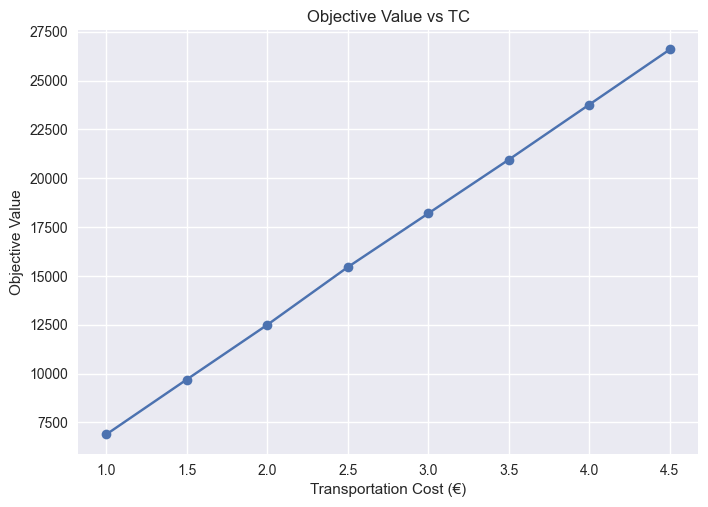

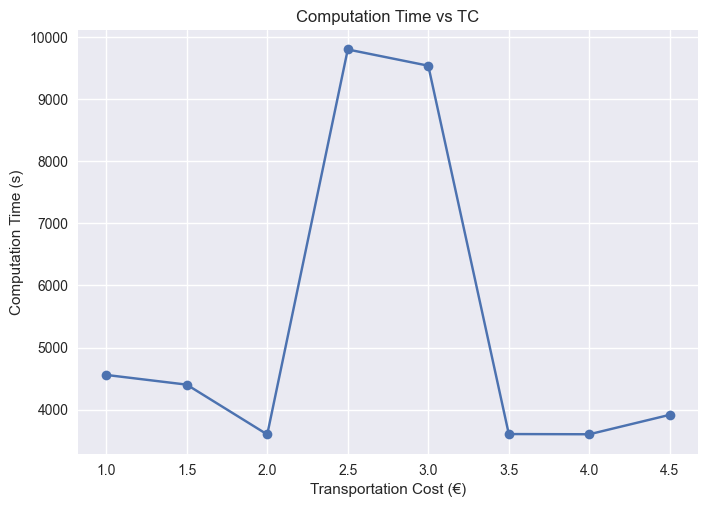

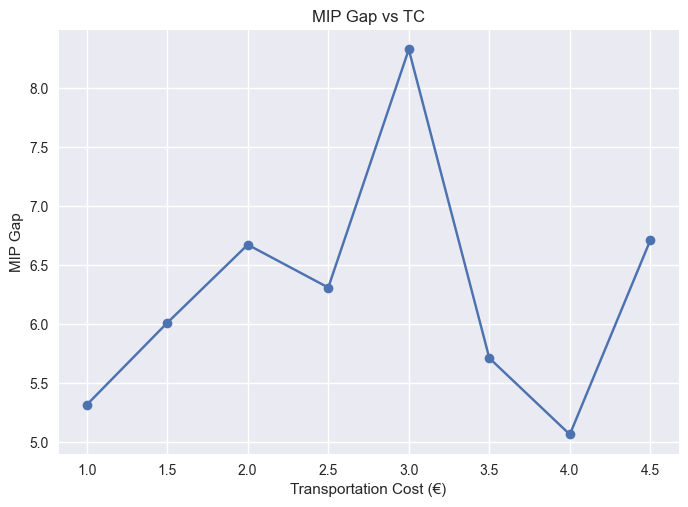

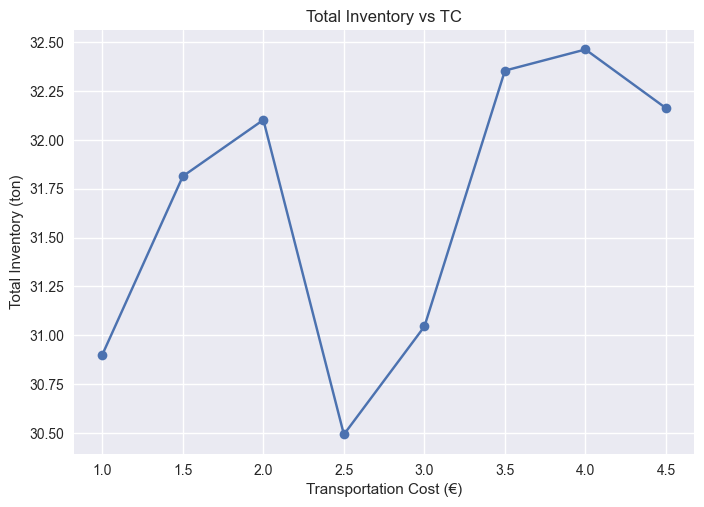

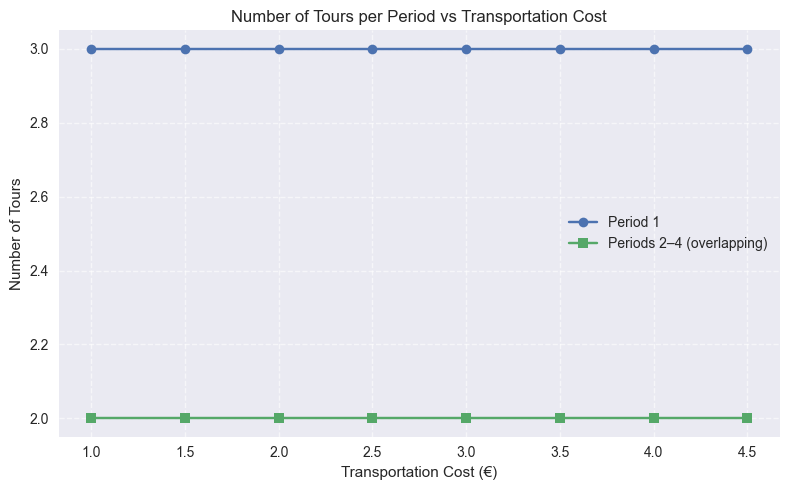

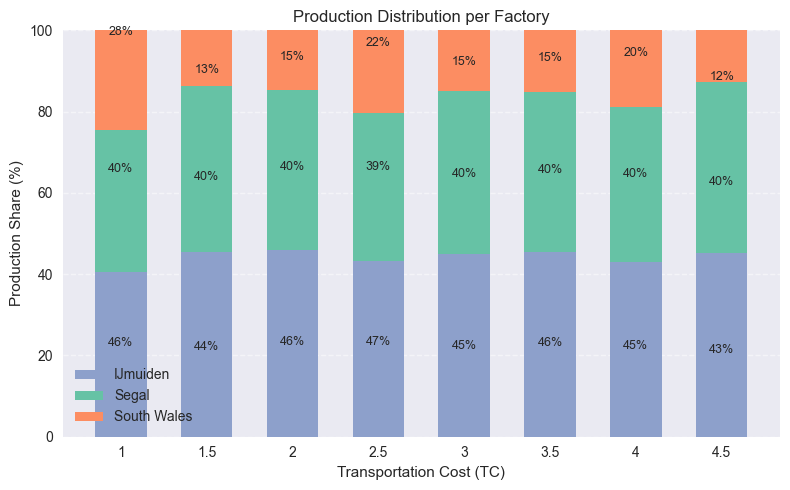

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8")

TC_values = [1,1.5,2,2.5,3,3.5,4,4.5]

#MIP-Gaps
mip_gap_new = [5.3159, 6.0115, 6.6741, 6.3107, 8.3297, 5.7128, 5.0648, 6.7128]

#obj value
plt.figure()
plt.plot(TC_values, obj_value, marker='o')
plt.xlabel("Transportation Cost (€)")
plt.ylabel("Objective Value")
plt.title("Objective Value vs TC")
plt.grid(True)
plt.show()

#comp time
plt.figure()
plt.plot(TC_values, comp_time, marker='o')
plt.xlabel("Transportation Cost (€)")
plt.ylabel("Computation Time (s)")
plt.title("Computation Time vs TC")
plt.grid(True)
plt.show()

#mip gap
plt.figure()
plt.plot(TC_values, mip_gap_new, marker='o')
plt.xlabel("Transportation Cost (€)")
plt.ylabel("MIP Gap")
plt.title("MIP Gap vs TC")
plt.grid(True)
plt.show()

#total inventory
plt.figure()
plt.plot(TC_values, total_inventory,  marker='o')
plt.xlabel("Transportation Cost (€)")
plt.ylabel("Total Inventory (ton)")
plt.title("Total Inventory vs TC")
plt.grid(True)
plt.show()

#tours per period
plt.figure(figsize=(8,5))

plt.plot(TC_values, amount_tours1, marker='o', label="Period 1")
plt.plot(TC_values, amount_tours2, marker='s', label="Periods 2–4 (overlapping)")
plt.xlabel("Transportation Cost (€)")
plt.ylabel("Number of Tours")
plt.title("Number of Tours per Period vs Transportation Cost")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

#production per factory
prod_ijm = np.array(prod_ijm)
prod_seg = np.array(prod_seg)
prod_sw = np.array(prod_sw)

total_prod = prod_ijm + prod_seg + prod_sw

ijm_pct = prod_ijm / total_prod * 100
seg_pct = prod_seg / total_prod * 100
sw_pct = prod_sw / total_prod * 100


x = np.arange(len(TC_values))
colors = ["#8da0cb", "#66c2a5", "#fc8d62"]
plt.figure(figsize=(8,5))
plt.bar(x, ijm_pct, width=0.6, color=colors[0], label="IJmuiden")
plt.bar(x, seg_pct, width=0.6, bottom=ijm_pct, color=colors[1], label="Segal")
plt.bar(
    x,
    sw_pct,
    width=0.6,
    bottom=np.array(ijm_pct) + np.array(seg_pct),
    color=colors[2],
    label="South Wales"
)

plt.xticks(x, TC_values)
plt.xlabel("Transportation Cost (€)")
plt.ylabel("Production Share (%)")
plt.title("Production Distribution per Factory")

for i in range(len(x)):

    # IJmuiden
    plt.text(x[i], prod_ijm[i]/2,
             f"{prod_ijm[i]:.0f}%", ha='center', va='center', fontsize=9)

    # Segal
    plt.text(x[i], prod_ijm[i] + prod_seg[i]/2,
             f"{prod_seg[i]:.0f}%", ha='center', va='center', fontsize=9)

    # South Wales
    plt.text(x[i], prod_ijm[i] + prod_seg[i] + prod_sw[i]/2,
             f"{prod_sw[i]:.0f}%", ha='center', va='center', fontsize=9)

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()